In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('./heart_clean.csv')

In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [8]:
df = df.dropna()

In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.946128
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,1.234551
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [24]:
df = pd.get_dummies(df, columns=['cp'], drop_first=True)


In [25]:
df = pd.get_dummies(df, columns=['restecg'], drop_first=True)

In [26]:
df = pd.get_dummies(df, columns=['thal'], drop_first=True)

In [27]:
df = pd.get_dummies(df, columns=['slope'], drop_first=True)

In [28]:
X = df.drop('target', axis=1)
y = df['target']
y = (y > 0).astype(int)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
"""from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['cp', 'restecg', 'thal', 'slope']  # whichever you're treating as nominal

encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])   # transform only, no fit

# get readable column names back
encoded_cols = encoder.get_feature_names_out(categorical_cols)"""

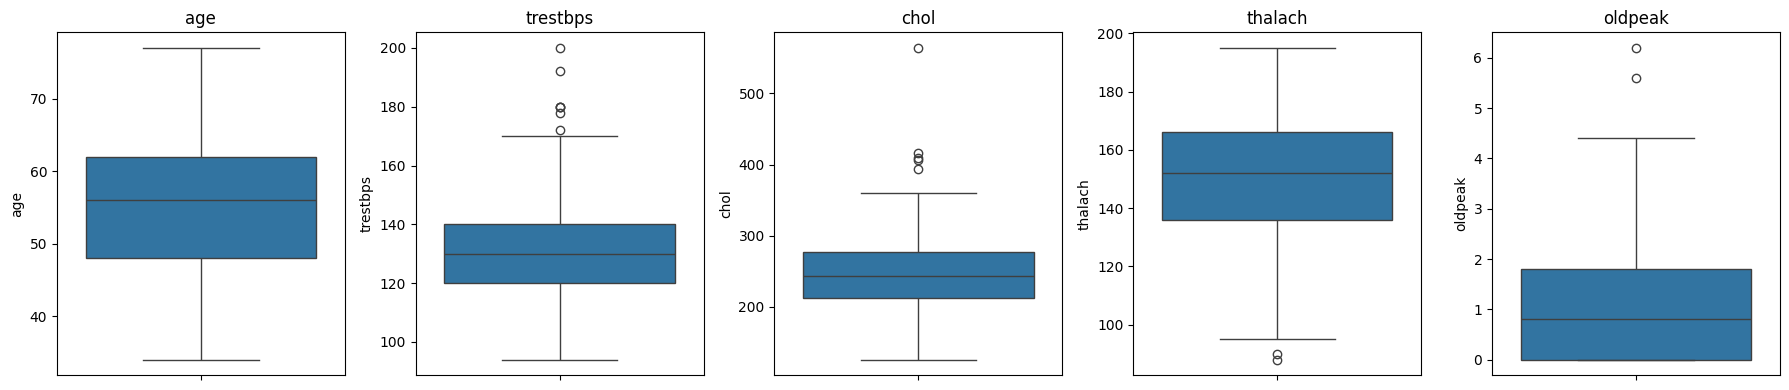

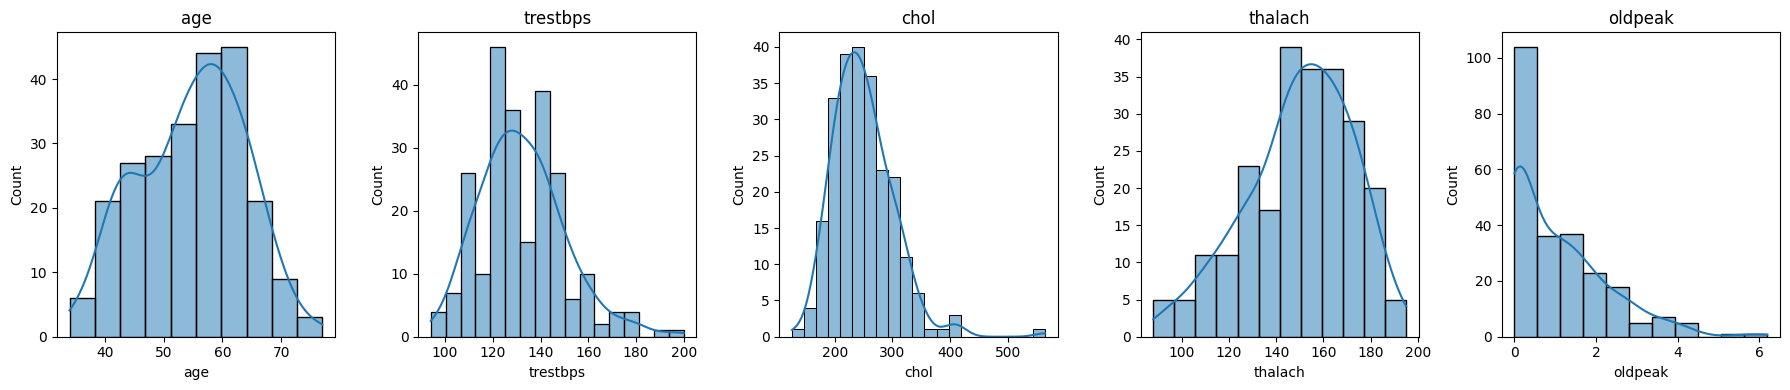

age        -0.159085
trestbps    0.668621
chol        1.318058
thalach    -0.490182
oldpeak     1.305929
dtype: float64

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Boxplots for outliers
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(18, 4))
for ax, col in zip(axes, continuous_cols):
    sns.boxplot(y=X_train[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Histograms for skew
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(18, 4))
for ax, col in zip(axes, continuous_cols):
    sns.histplot(X_train[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Numeric skew values — a clean way to justify your choice without eyeballing only
X_train[continuous_cols].skew()

In [30]:
"""from sklearn.preprocessing import RobustScaler

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = RobustScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])"""

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('standard', StandardScaler(), ['age']),
    ('robust', RobustScaler(), ['trestbps', 'chol', 'thalach', 'oldpeak']),
], remainder='passthrough')

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [31]:
"""from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder

categorical_cols = ['cp', 'restecg', 'thal', 'slope']

preprocessor = ColumnTransformer(transformers=[
    ('standard', StandardScaler(), ['age']),
    ('robust', RobustScaler(), ['trestbps', 'chol', 'thalach', 'oldpeak']),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
], remainder='passthrough')  # passes sex, fbs, exang through unchanged — already 0/1

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)"""

"from sklearn.compose import ColumnTransformer\nfrom sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder\n\ncategorical_cols = ['cp', 'restecg', 'thal', 'slope']\n\npreprocessor = ColumnTransformer(transformers=[\n    ('standard', StandardScaler(), ['age']),\n    ('robust', RobustScaler(), ['trestbps', 'chol', 'thalach', 'oldpeak']),\n    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),\n], remainder='passthrough')  # passes sex, fbs, exang through unchanged — already 0/1\n\nX_train_processed = preprocessor.fit_transform(X_train)\nX_test_processed = preprocessor.transform(X_test)"

In [32]:
y_train.value_counts(normalize=True)

target
0    0.540084
1    0.459916
Name: proportion, dtype: float64